# SENTINEL ANALYSIS WITH SHAPEFILE DELINEATIONS

In [1]:
import rasterio
from rasterio import plot
import matplotlib.pyplot as plt
import numpy as np
import os, glob
from array import array
import csv
import pandas as pd
import struct
import re
from numpy import asarray
from numpy import savetxt
import matplotlib
import math
import time
from  datetime import datetime
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import matplotlib.patheffects as path_effects
import shapefile
import geopandas as gpd
from matplotlib.colorbar import Colorbar

### Main parameters

In [2]:
#general_path = "/home/azaninetti/Documents/Thesis/case_study_2022_06_15/" #CHN
base_path = "/media/moi/Elements/Antoine/Thesis_2023_06_05/"
general_path = base_path + "New_blue_ice/"
#fold_path = general_path + "Landsat/"
save_path = base_path + "Results/"

sat = "Sentinel"

### Find the folders containing the tiff pictures

In [3]:
foldList = os.listdir(general_path)
f = len(foldList)
print("List of directories:", foldList)
foldList.sort()


List of directories: ['Full_2017_08_10', 'Full_2018_08_10', 'Full_2018_10_17', 'Full_2019_05_05', 'Full_2020_04_24', 'Full_2020_05_21', 'Full_2020_05_21_2', 'Full_2020_05_21_3', 'Full_2020_06_17', 'Full_2020_06_27', 'Full_2020_06_27_2', 'Full_2020_07_30', 'Full_2021_03_04', 'Full_2021_03_04_2', 'Full_2021_05_01', 'Full_2021_05_03', 'Full_2021_05_04', 'Full_2021_05_14', 'Full_2021_05_14_2', 'Full_2021_05_14_3', 'Full_2021_09_18', 'Full_2021_09_18_2', 'Full_2021_09_18_3', 'Full_2022_05_11', 'Full_2022_07_28', 'Full_2022_10_03', 'Full_2022_10_03_2', 'Full_2022_10_03_3']


### Run the file contaning the functions 

In [4]:
%run FUNCTIONS.ipynb

In [5]:
if sat == 'Sentinel':
    b = 12
if sat == 'Landsat':
    b = 8

mean_val = np.zeros([b,f]) # Each column is an event with all the bands
std_val = np.zeros([b,f])
median_val = np.zeros([b,f])

diff_index = np.zeros([f,b,b])
ratios_matrix = np.zeros([f,b,b])

ratios_matrix_std = np.zeros([f,b,b])
diff_index_std = np.zeros([f,b,b])

STR_mean = np.zeros(f)
STR_std = np.zeros(f)

thermal = 1

rast_dc = {}
rast_dc_corr = {} 
bounds_dc = {}
data = {}

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2017_08_10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


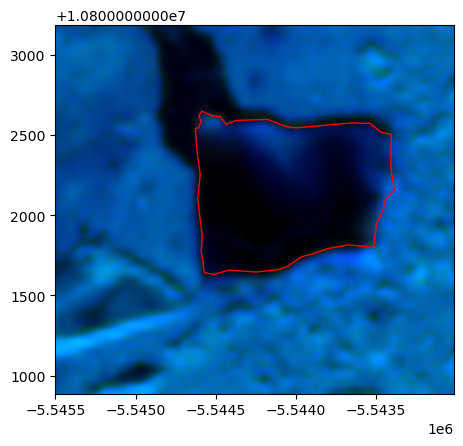

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2018_08_10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


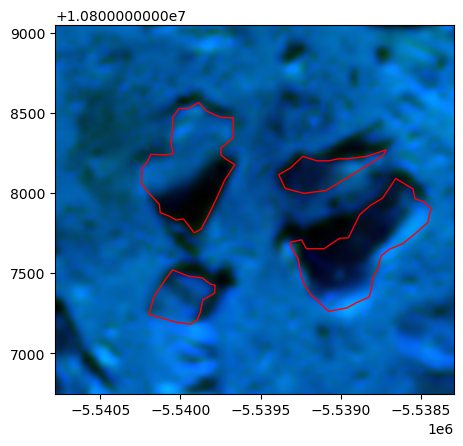

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2018_10_17


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


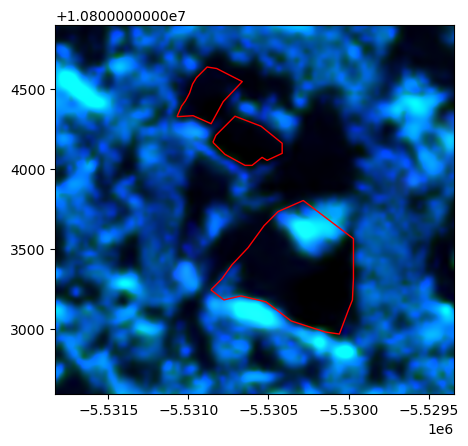

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2019_05_05


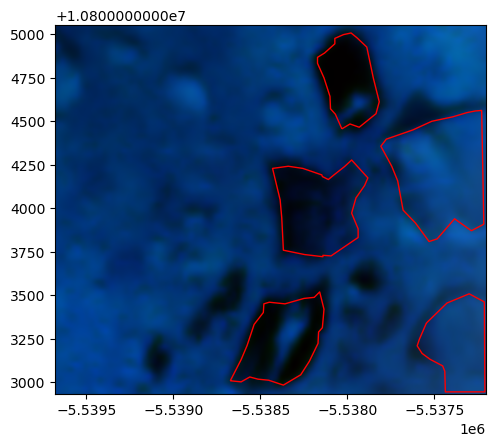

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_04_24


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


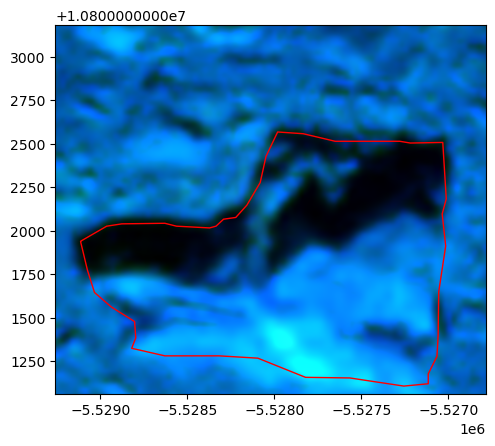

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_05_21


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


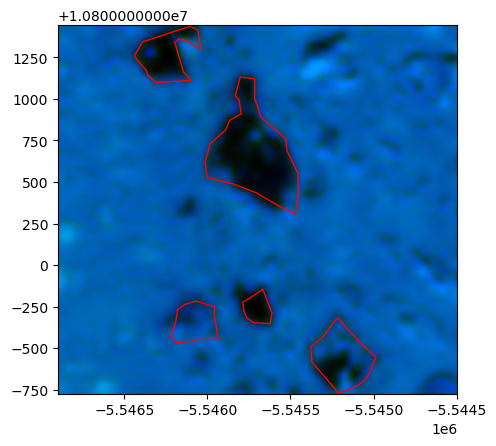

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_05_21_2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


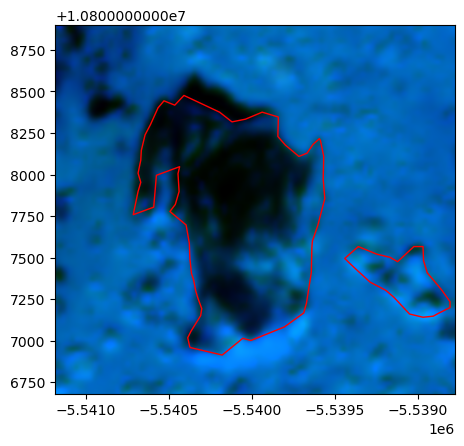

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_05_21_3


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


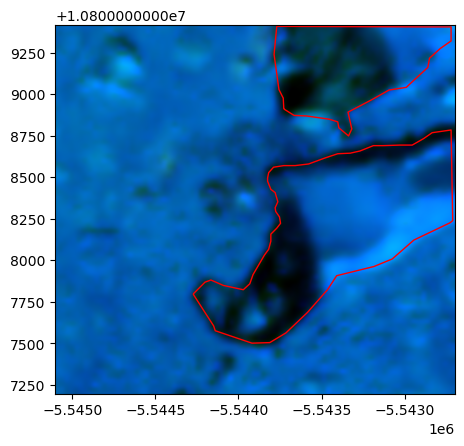

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_06_17


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


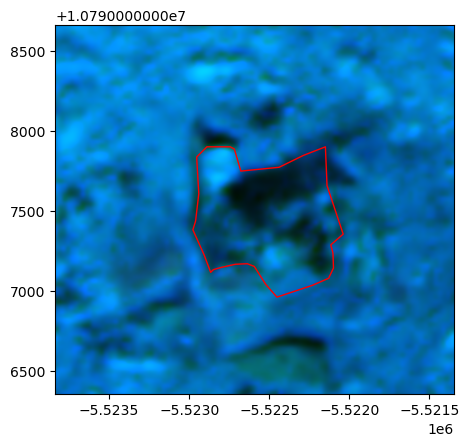

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_06_27


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


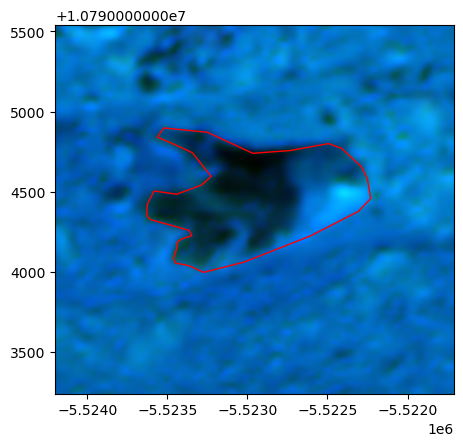

In [6]:
for j in range(10):
  
    path = general_path + foldList[j]
    print(path)
        
    read_and_store(path, j, f) 
    plot_SWIR(foldList[j], path, data,bounds_dc)



/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_06_27_2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


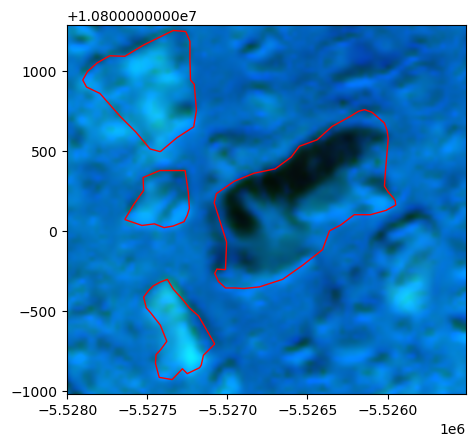

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2020_07_30


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


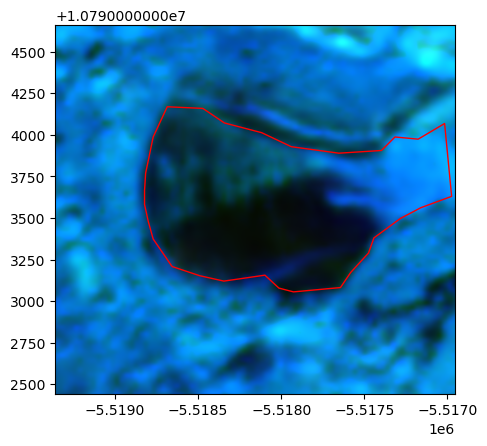

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2021_03_04


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


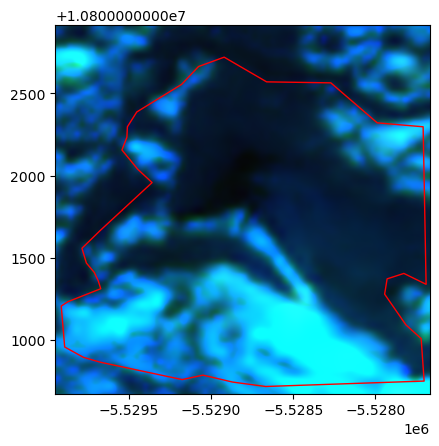

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2021_03_04_2


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


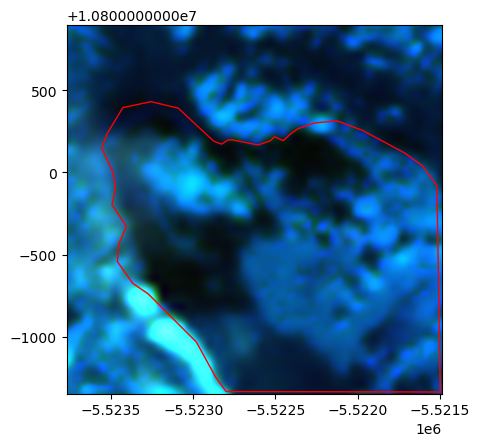

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2021_05_01


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


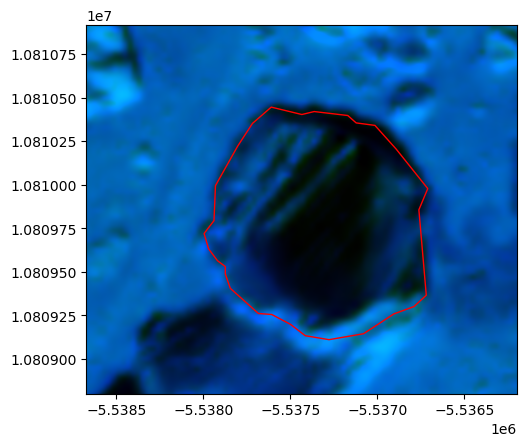

/media/moi/Elements/Antoine/Thesis_2023_06_05/New_blue_ice/Full_2021_05_03


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


In [ ]:
for j in range(10, 20):
  
    path = general_path + foldList[j]
    print(path)
        
    read_and_store(path, j, f) 
    plot_SWIR(foldList[j], path, data,bounds_dc)



In [ ]:
for j in range(20,f):
  
    path = general_path + foldList[j]
    print(path)
        
    read_and_store(path, j, f) 
    plot_SWIR(foldList[j], path, data,bounds_dc)

